In [13]:
# basic impoorts
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
#import seaborn as sns
import numpy as np
#import re
#import string
%matplotlib inline

# machine learning imports
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

from joblib import dump

# Bias Detection Models

This notebook contains the code for three different news bias detection models.  A Random Forest Model, a Support Vector Machine Model, and a Linear Regression Model.  

## Vectorization

Before running any of the models, we will define and apply a vectorizer.  We remove words that appear in more than 95 percent of articles or less than 2 percent of articles.

In [2]:
# load dataset and reset index
filename = "kaggleClean.json" # this can be changed depending upon which dataset we use.  
df_final = pd.read_json(filename)
df_final.reset_index(drop=True, inplace=True)
df_final.head() 

,label,text
0,0,got us many hobby relationship legged pal got ...
1,0,new year eve gathering could accelerate covid ...
2,1,country around world ringing much world bade s...
3,0,police wisconsin thursday evening arrested hos...
4,1,wisconsinbased hospital wednesday employee rem...


In [3]:
# define and apply text vectorization
vec_text = CountVectorizer(
    max_df= 0.95,
    min_df= 2,
    ngram_range= (1, 3) # unigrams (single words), and bigrams (word pairs)
)

X_text = vec_text.fit_transform(df_final["text"])

X_text

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5674725 stored elements and shape (9354, 740634)>

In [15]:
dump(vec_text, "vec_text.joblib")

['vec_text.joblib']

#### Define X and Y and create training and run train test split.

In [4]:
# define X and Y
# make sure number of rows are equal
X = X_text
y = df_final["label"]
print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

(9354, 740634)
(9354,)


#### Decision Tree Model

We knew from research that a decision tree was unlikely to perform well but we testing one anyway.  A grid search was too time consuming to parameters were fine tuned mannualy.  We achieved accuracy of .61 using the Hugging Face Data Set and .77 using the Kaggle Dataset.

In [5]:
model_decTree = DecisionTreeClassifier(
    criterion = "log_loss",
    max_depth = 7,
    min_samples_split= 2,
    min_samples_leaf= 1,
    random_state= 42
)
model_decTree.fit(X_train, y_train)
y_pred = model_decTree.predict(X_test)

In [6]:
# look at results from decision tree
dt_accuracy = accuracy_score(y_test, y_pred)
dt_accuracy

0.7698610616316351

In [14]:
dump(model_decTree, "model_decTree.joblib")

['model_decTree.joblib']

### Linear SVC Model

We next tried a Linear Support Vector Machine.  We used a grid search to optimize parameters.  We slowly narrowed in parameters so this is only the final test.  

In [7]:
model_svc = LinearSVC(random_state= 42)

grid_params_svc = {
    "penalty": ["l2"],
    "loss": ["squared_hinge"],
    "dual": [False],
    "C": [0.03, 0.04, 0.05],
    "tol": [1.2e-3],
    "max_iter": [2000]
}

grid_search_svc = GridSearchCV(
    estimator= model_svc,
    param_grid= grid_params_svc,
    cv= 5, 
    n_jobs= 1
)

grid_search_svc.fit(X_train, y_train)

grid_best_params = grid_search_svc.best_params_
grid_best_estimator_svc = grid_search_svc.best_estimator_

y_test_pre = grid_best_estimator_svc.predict(X_test)

grid_test_metrics_svc = {
    'accuracy': accuracy_score(y_test, y_test_pre)
}


grid_test_metrics_svc

{'accuracy': 0.8161738510865693}

In [16]:
dump(grid_best_estimator_svc, "grid_best_estimator_svc.joblib")

['grid_best_estimator_svc.joblib']

### Logistic Regression Model

Because we ultimately wanted to capture the probability of an article pertaining to each class, we decided to test a logistic regression model.  We found it performed almost identical to the SVM but Logistic Regression has the predict_proba_ function allowing us to easily extract probabilities.  Our accuracy, precision, revall and f1 scores were all approximately .82.  

In [8]:
model3 = LogisticRegression(random_state= 42)

grid_params3 = {
    "solver": ["lbfgs", 'liblinear'],
    "penalty": ["l2"],
    "dual": [False],
    "C": [.25, .5, .75],
    "tol": [1e-4, 1.5e-4, 1.75e-4],
    "max_iter": [2000]
}

grid_search3 = GridSearchCV(
    estimator= model3,
    param_grid= grid_params3,
    cv= 5, 
    n_jobs= 1
)

grid_search3.fit(X_train, y_train)

grid_best_params_3 = grid_search3.best_params_
grid_best_estimator_3 = grid_search3.best_estimator_

y_test_pre_3 = grid_best_estimator_3.predict(X_test)


grid_test_metrics_3 = {
    'accuracy': accuracy_score(y_test, y_test_pre_3),
    'precision': precision_score(y_test, y_test_pre_3, average= 'weighted'), 
    'recall': recall_score(y_test, y_test_pre_3, average= 'weighted'),
    'f1 score': f1_score(y_test, y_test_pre_3, average= 'weighted')
}

grid_results3 = pd.DataFrame(grid_search3.cv_results_)

grid_test_metrics_3

{'accuracy': 0.8297114356964731,
 'precision': 0.8296848950783458,
 'recall': 0.8297114356964731,
 'f1 score': 0.8295899346588262}

In [9]:
# looking at optimal parameters
grid_best_params_3 

{'C': 0.25,
 'dual': False,
 'max_iter': 2000,
 'penalty': 'l2',
 'solver': 'liblinear',
 'tol': 0.0001}

In [17]:
dump(grid_best_estimator_3, "grid_best_estimator_logreg.joblib")

['grid_best_estimator_logreg.joblib']

## Results and Analysis

TO better understand how the model was performing, we created a confusion matrix and plotted the top features our model relied on to make predictions.  

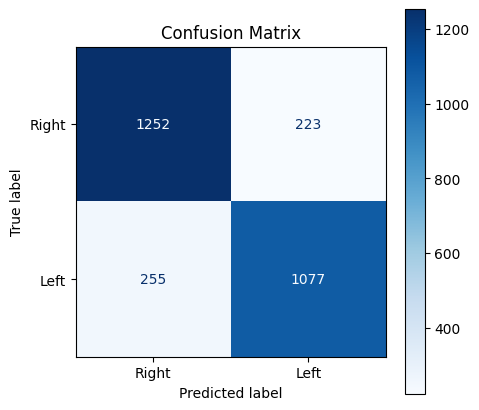

In [10]:
cm = confusion_matrix(y_test, y_test_pre_3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Right", "Left"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

In [11]:
# extract top features from linear regression model
feature_names = vec_text.get_feature_names_out()
importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": grid_best_estimator_3.coef_[0],
    "importance_abs": abs(grid_best_estimator_3.coef_[0])
}).sort_values("importance_abs", ascending=False)

importance.head(30)

,feature,coefficient,importance_abs
117916,click,1.230713,1.230713
709139,washington examiner,0.859164,0.859164
220351,examiner,0.831084,0.831084
529665,recommended,0.791372,0.791372
498462,president trump,0.753979,0.753979
264627,get fox,0.706793,0.706793
117964,click read,0.636112,0.636112
500150,press contributed report,0.576088,0.576088
500148,press contributed,0.560522,0.560522
48787,associated press contributed,0.560522,0.560522


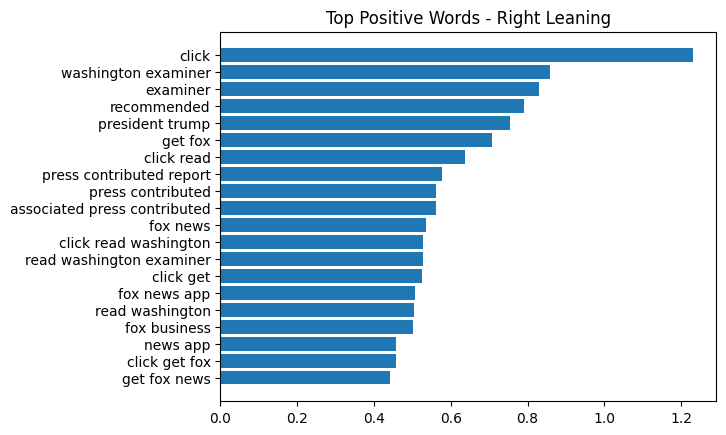

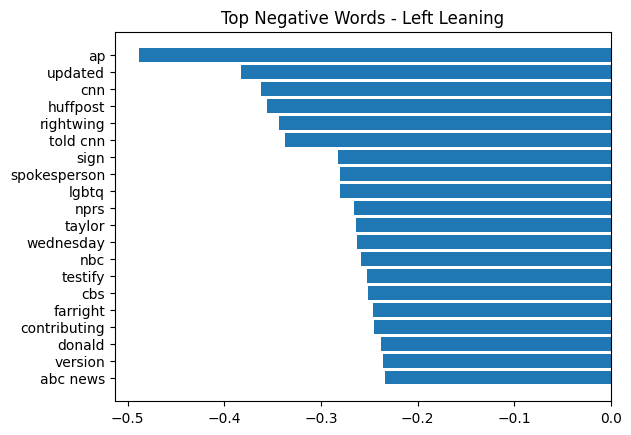

In [12]:
# plot the top 20 features for each class
top_positive = importance.sort_values(by='coefficient', ascending=False).head(20)
top_negative = importance.sort_values(by='coefficient').head(20)

# Positive words
plt.figure()
plt.barh(top_positive['feature'], top_positive['coefficient'])
plt.title("Top Positive Words - Right Leaning")
plt.gca().invert_yaxis()
plt.show()

# Negative words
plt.figure()
plt.barh(top_negative['feature'], top_negative['coefficient'])
plt.title("Top Negative Words - Left Leaning")
plt.gca().invert_yaxis()
plt.show()

## Further Testing

The Linear Regression model trained on the Hugging Face Dataset had the highest overall accuracy.  However, in order to see how our model would generalize to data from various time frames and genres, we tested the model using the BIGNEWS dataset.  The BIGNEWS dataset is a very large dataset of 2.5 million + articles.  The articles have been scraped from various news websites that are known to be left-leaning, right-leaning or nuetral.  I took a subset of 90,000 articles, 45,000 from left-leaning articles and 45,000 from right-leaning articles.  I cleaned this subset and replaced the source columns with a bias code of 0 for left or 1 for right, to match my other datasets.  I then used the cleaned subset to test the Linear Regression model. With the Linear Regression model trained on the hugging face dataset (Twitter posts and short statements), I achieved less than 50 percent accuracy with the test data.  With the same model, trained on the Kaggle dataset, we achieved over 60% accuracy.  While this is still low, the improvement was considerable and led us to believe that the model trained on the longer, Kaggle articles generalizes better to a wide variety of topics.  

This testing code is not included as the dataset was obtained with a one time code that was emailed to us upon providing the intended use of the dataset.  The dataset is too large to include here.